생선 데이터

In [44]:
fish_length = [25.4, 26.3, 26.5, 29.0, 29.0, 29.7, 29.7, 30.0, 30.0, 30.7, 31.0, 31.0, 
                31.5, 32.0, 32.0, 32.0, 33.0, 33.0, 33.5, 33.5, 34.0, 34.0, 34.5, 35.0, 
                35.0, 35.0, 35.0, 36.0, 36.0, 37.0, 38.5, 38.5, 39.5, 41.0, 41.0, 9.8, 
                10.5, 10.6, 11.0, 11.2, 11.3, 11.8, 11.8, 12.0, 12.2, 12.4, 13.0, 14.3, 15.0]
fish_weight = [242.0, 290.0, 340.0, 363.0, 430.0, 450.0, 500.0, 390.0, 450.0, 500.0, 475.0, 500.0, 
                500.0, 340.0, 600.0, 600.0, 700.0, 700.0, 610.0, 650.0, 575.0, 685.0, 620.0, 680.0, 
                700.0, 725.0, 720.0, 714.0, 850.0, 1000.0, 920.0, 955.0, 925.0, 975.0, 950.0, 6.7, 
                7.5, 7.0, 9.7, 9.8, 8.7, 10.0, 9.9, 9.8, 12.2, 13.4, 12.2, 19.7, 19.9]

두 리스트를 연결

In [45]:
import numpy as np

fish_data = np.column_stack((fish_length, fish_weight))
print(fish_data)

[[  25.4  242. ]
 [  26.3  290. ]
 [  26.5  340. ]
 [  29.   363. ]
 [  29.   430. ]
 [  29.7  450. ]
 [  29.7  500. ]
 [  30.   390. ]
 [  30.   450. ]
 [  30.7  500. ]
 [  31.   475. ]
 [  31.   500. ]
 [  31.5  500. ]
 [  32.   340. ]
 [  32.   600. ]
 [  32.   600. ]
 [  33.   700. ]
 [  33.   700. ]
 [  33.5  610. ]
 [  33.5  650. ]
 [  34.   575. ]
 [  34.   685. ]
 [  34.5  620. ]
 [  35.   680. ]
 [  35.   700. ]
 [  35.   725. ]
 [  35.   720. ]
 [  36.   714. ]
 [  36.   850. ]
 [  37.  1000. ]
 [  38.5  920. ]
 [  38.5  955. ]
 [  39.5  925. ]
 [  41.   975. ]
 [  41.   950. ]
 [   9.8    6.7]
 [  10.5    7.5]
 [  10.6    7. ]
 [  11.     9.7]
 [  11.2    9.8]
 [  11.3    8.7]
 [  11.8   10. ]
 [  11.8    9.9]
 [  12.     9.8]
 [  12.2   12.2]
 [  12.4   13.4]
 [  13.    12.2]
 [  14.3   19.7]
 [  15.    19.9]]


In [46]:
#일렬로 나열
fish_target = np.concatenate((np.ones(35), np.zeros(14)))
print(fish_target)

[1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0.]


사이킷런으로 데이터 나누기

In [47]:
from sklearn.model_selection import train_test_split

#정답의 비율대로 train과 test에 나누어줌
train_input, test_input, train_target, test_target = train_test_split(fish_data, fish_target, stratify=fish_target, random_state=42)
print(test_target)

[0. 0. 1. 0. 1. 0. 1. 1. 1. 1. 1. 1. 1.]


k최근접

In [48]:
from sklearn.neighbors import KNeighborsClassifier

kn = KNeighborsClassifier()
kn.fit(train_input, train_target)
kn.score(test_input, test_target)

1.0

In [49]:
print(kn.predict([[25, 150]]))

[0.]


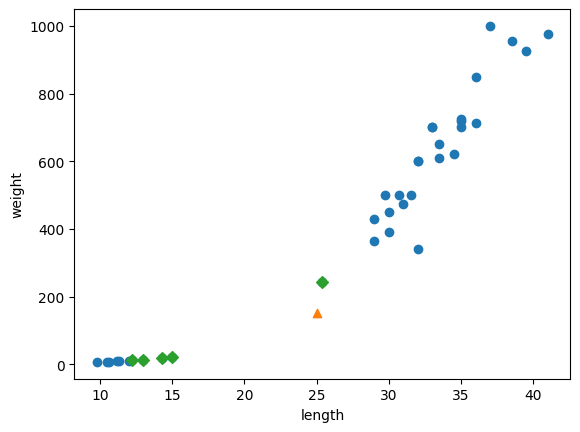

In [50]:
# distance에 거리를 저장, index에 이웃의 번호 저장
distances, indexes = kn.kneighbors([[25, 150]])

import matplotlib.pyplot as plot

plot.scatter(train_input[:,0], train_input[:,1])
plot.scatter(25, 150, marker='^')
plot.scatter(train_input[indexes,0],train_input[indexes,1], marker='D')
plot.xlabel('length')
plot.ylabel('weight')
plot.show()

스케일이 맞지 않으므로 동일한 범위로 만들기

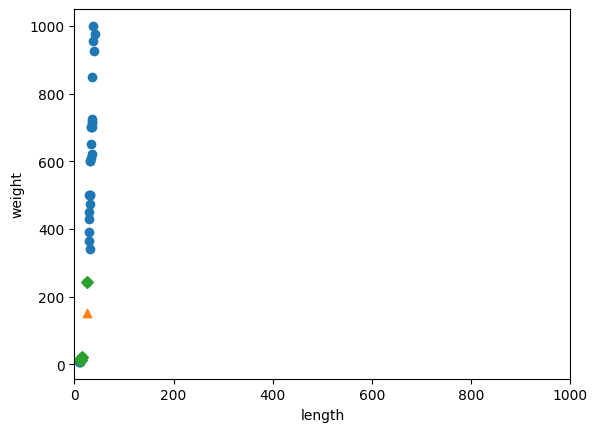

In [51]:
plot.scatter(train_input[:,0], train_input[:,1])
plot.scatter(25, 150, marker='^')
plot.scatter(train_input[indexes,0],train_input[indexes,1], marker='D')
plot.xlim((0,1000))
plot.xlabel('length')
plot.ylabel('weight')
plot.show()

표준 점수로 바꾸기

In [52]:
#mean 평균 , std 표준편차, axis=0 열 별로 구하기
mean = np.mean(train_input, axis=0)
std = np.std(train_input, axis=0)

train_scaled = (train_input - mean) / std

산점도 다시 그리기

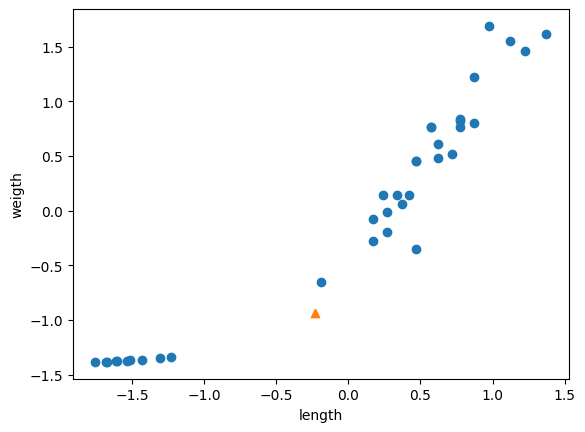

In [53]:
new = ([25, 150]-mean)/std
plot.scatter(train_scaled[:,0], train_scaled[:,1])
plot.scatter(new[0], new[1], marker='^')
plot.xlabel('length')
plot.ylabel('weigth')
plot.show()

변환된 데이터를 통해 모델 훈련

[1.]


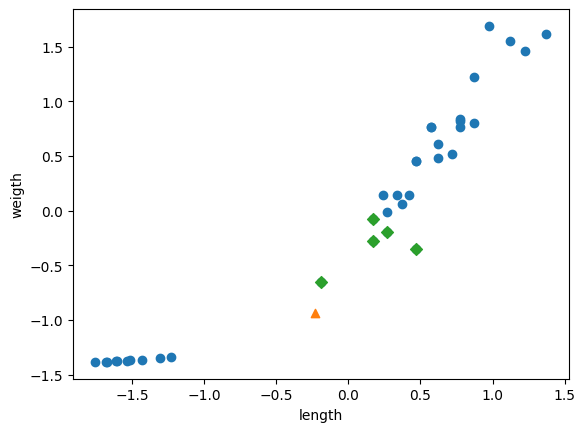

In [54]:
kn.fit(train_scaled, train_target)

test_scaled = (test_input-mean)/std
kn.score(test_scaled, test_target)

print(kn.predict([new]))

distances, indexes = kn.kneighbors([new])

plot.scatter(train_scaled[:,0], train_scaled[:,1])
plot.scatter(new[0], new[1], marker='^')
plot.scatter(train_scaled[indexes,0], train_scaled[indexes,1], marker='D')
plot.xlabel('length')
plot.ylabel('weigth')
plot.show()